# Opis

Notatnik służący do wizualizacji przestrzeni ukrytej autoenkoderów

In [1]:
IS_NEW_APPROACH = True
IS_VGAE = True

# Importy

In [2]:
%load_ext autoreload
%autoreload 2
import json
import matplotlib.pyplot as plt

import sys

sys.path.append('../')
import torch
from utils.FramsticksGraphDataset import FramsticksGraphDataset
from pyprojroot import here
from src.models.KlejdaGAE.KlejdaGraphAutoencoder import KlejdaGraphAutoencoder
from src.models.KlejdaGAE.KlejdaVariationalGraphAutoencoder import KlejdaVariationalGraphAutoencoder
from src.models.NewGAE.GraphAutoencoder import GraphAutoencoder
from src.models.NewGAE.VariationalGraphAutoencoder import VariationalGraphAutoencoder
import yaml
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import kaleido
import plotly
import plotly.express as px
import pandas as pd
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots

current_dir = os.getcwd()
framspy_path = os.path.abspath(os.path.join(current_dir, '..', 'external', 'framspy'))
if framspy_path not in sys.path:
	sys.path.insert(0, framspy_path)
with open("../configs/final_evolution_config.yaml", 'r') as f:
	evolution_config = yaml.safe_load(f)
import frams

frams.init(
	evolution_config['frams_path']
)

genotypes = []
with open("../results/sampled_best_individuals_new_mini_merged.jsonl", "r", encoding="utf-8") as f:
	for line in f:
		obj = json.loads(line.strip())
		genotypes.append(obj)


C:\Users\witek\PycharmProjects\Magisterka\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




Using Framsticks version: 5.5
Home (writable) dir     : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data
Resources dir           : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data



# Przygotowanie autoenkodera

In [3]:
project_dir = here()
# Przygotowanie checkpointów nauczonych autoenkoderów
checkpoints_dir = project_dir / 'notebooks' / 'checkpoints' / 'final_checkpoints'

if IS_NEW_APPROACH:
	checkpoints_dir = checkpoints_dir / 'new'
else:
	checkpoints_dir = checkpoints_dir / 'klejda'
checkpoint_gae = torch.load(checkpoints_dir / 'gae.ckpt')
checkpoint_vgae = torch.load(checkpoints_dir / 'vgae.ckpt')
# Przygotowanie konfiguracji dla gae
configs_dir = project_dir / 'configs'

if IS_NEW_APPROACH:
	config_gae_path = configs_dir / 'gae_config_large.yaml'
	config_vgae_path = configs_dir / 'gae_config_large.yaml'
else:
	config_gae_path = configs_dir / 'klejda_gae_config.yaml'
	config_vgae_path = configs_dir / 'klejda_gae_config.yaml'

with open(config_gae_path) as f:
	config_gae = yaml.safe_load(f)
with open(config_vgae_path) as f:
	config_vgae = yaml.safe_load(f)
torch.set_printoptions(precision=10)

## Przygotowanie macierzy wektorów ukrytych

In [4]:
NUMBER_OF_EXAMPLES = 1000

dataset = FramsticksGraphDataset(genotypes, config_gae["max_nodes"])
dataset_size = len(dataset)

dataloader = DataLoader(
	dataset,
	batch_size=1,
	shuffle=True,
	num_workers=2,
	persistent_workers=True
)

if IS_VGAE:
	if IS_NEW_APPROACH:
		autoencoder = VariationalGraphAutoencoder(config=config_vgae, frams_module=frams)
	else:
		autoencoder = KlejdaVariationalGraphAutoencoder(config=config_vgae, frams_module=frams)
	autoencoder.load_state_dict(checkpoint_vgae['state_dict'])
else:
	if IS_NEW_APPROACH:
		autoencoder = GraphAutoencoder(config=config_gae, frams_module=frams)
	else:
		autoencoder = KlejdaGraphAutoencoder(config=config_gae, frams_module=frams)
	autoencoder.load_state_dict(checkpoint_gae['state_dict'])

device = torch.device("cpu")
autoencoder = autoencoder.to(device)

autoencoder.eval()

latent_vectors = []
labels = []

with torch.no_grad():
	for i, batch in enumerate(dataloader):
		if i >= NUMBER_OF_EXAMPLES:
			break
		# Rozpakowanie batcha
		x_matrix = batch[0]
		a_matrix = batch[1]
		label = batch[2][config_gae['locality_loss_type']].squeeze(0).tolist()
		if config_gae['locality_loss_type'] == 'fitness':
			label = label[0]
		labels.append(label)
		z = autoencoder.encode(x_matrix, a_matrix)
		# Spakowanie do batcha
		z_single = z.squeeze(0)

		latent_vectors.append(z_single)
latent_vectors = np.array(latent_vectors)
print(f"Pomyślnie wygenerowano {len(latent_vectors)} wektorów ukrytych.")
# Przykładowy podgląd kształtu pierwszego wektora
print(f"Kształt pojedynczego wektora z: {latent_vectors[0].shape}")
# print(f"Labels: {labels}")

Pomyślnie wygenerowano 1000 wektorów ukrytych.
Kształt pojedynczego wektora z: (15,)


# Wizualizacja przestrzeni ukrytej

## PCA 2D

Generowanie wizualizacji PCA dla fitnessu...


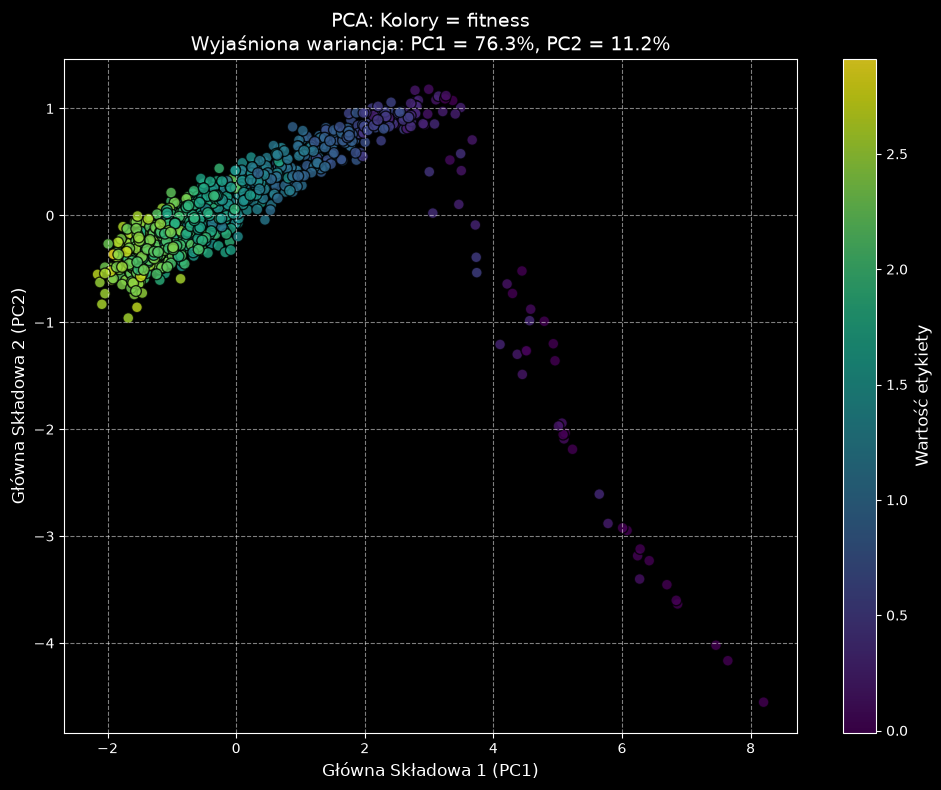

In [8]:
def visualize_pca_2d(latent_vectors, labels, title="Wizualizacja PCA przestrzeni ukrytej (2D)"):
	# 1. Konwersja listy tensorów PyTorch na jedną, płaską macierz Numpy
	if isinstance(latent_vectors[0], torch.Tensor):
		z_matrix = torch.stack(latent_vectors).numpy()
	else:
		z_matrix = np.array(latent_vectors)

	labels = np.array(labels)

	assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

	pca = PCA(n_components=2)
	z_pca = pca.fit_transform(z_matrix)

	explained_variance = pca.explained_variance_ratio_ * 100

	plt.figure(figsize=(10, 8))

	# Wykres punktowy
	scatter = plt.scatter(
		z_pca[:, 0],
		z_pca[:, 1],
		c=labels,
		cmap='viridis',
		marker='o',
		edgecolors='black',
		alpha=0.8,
		s=60
	)

	cbar = plt.colorbar(scatter)
	cbar.set_label('Wartość etykiety', fontsize=12)

	# for i, label in enumerate(labels):
	#     formatted_label = f"{label:.2f}" if isinstance(label, float) else str(label)
	#
	#     plt.annotate(
	#         formatted_label,
	#         (z_pca[i, 0], z_pca[i, 1]),
	#         textcoords="offset points",
	#         xytext=(5, 4),
	#         ha='left',
	#         fontsize=8,
	#         alpha=0.95
	#     )

	plt.title(f'{title}\nWyjaśniona wariancja: PC1 = {explained_variance[0]:.1f}%, PC2 = {explained_variance[1]:.1f}%',
			  fontsize=14)
	plt.xlabel(f'Główna Składowa 1 (PC1)', fontsize=12)
	plt.ylabel(f'Główna Składowa 2 (PC2)', fontsize=12)
	plt.grid(True, linestyle='--', alpha=0.5)

	plt.tight_layout()
	plt.show()


print("Generowanie wizualizacji PCA dla fitnessu...")
visualize_pca_2d(latent_vectors, labels, title=f"PCA: Kolory = {config_gae['locality_loss_type']}")


## PCA 3D

In [5]:
if isinstance(latent_vectors[0], torch.Tensor):
	z_matrix = torch.stack(latent_vectors).numpy()
else:
	z_matrix = np.array(latent_vectors)

pca3d = PCA(n_components=3)
z_pca = pca3d.fit_transform(z_matrix)


def visualize_pca_3d_interactive(pca3d, labels, title="Interaktywne PCA 3D"):
	labels = np.array(labels)
	assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

	exp_var = pca3d.explained_variance_ratio_ * 100

	hover_texts = [f"Wartość: {lbl:.3f}" if isinstance(lbl, float) else f"Wartość: {lbl}" for lbl in labels]

	df = pd.DataFrame({
		'PC1': z_pca[:, 0],
		'PC2': z_pca[:, 1],
		'PC3': z_pca[:, 2],
		'Etykieta': labels,
		'Szczegóły': hover_texts
	})

	fig = px.scatter_3d(
		df,
		x='PC1',
		y='PC2',
		z='PC3',
		color='Etykieta',  # Kolorowanie na podstawie przekazanych etykiet (np. fitness)
		hover_name='Szczegóły',  # Tekst pojawiający się po najechaniu myszką
		title=f'{title} (Zachowana wariancja: {sum(exp_var):.1f}%)',
		labels={
			'PC1': f'PC1 ({exp_var[0]:.1f}%)',
			'PC2': f'PC2 ({exp_var[1]:.1f}%)',
			'PC3': f'PC3 ({exp_var[2]:.1f}%)'
		},
		color_continuous_scale='Viridis',  # Ładna i czytelna mapa kolorów
		opacity=0.85
	)

	fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

	fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

	fig.show()


visualize_pca_3d_interactive(pca3d, labels, title="PCA 3D: Kolory = Fitness")

# Generator struktury 3D pojedynczego osobnika

In [12]:
def get_plotly_traces(X, A, node_color='#1f77b4', edge_color='#7f8c8d'):
    """Zwraca ślady (traces) dla pojedynczego osobnika w Plotly, z dynamicznym podłożem."""
    x, y, z = X[:, 0], X[:, 1], X[:, 2]

    # 1. Krawędzie
    edge_x, edge_y, edge_z = [], [], []
    n = A.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > 0.5:
                edge_x.extend([x[i], x[j], None])
                edge_y.extend([y[i], y[j], None])
                edge_z.extend([z[i], z[j], None])

    trace_edges = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines',
        line=dict(color=edge_color, width=8),
        hoverinfo='none',
        showlegend=False
    )

    # 2. Węzły
    trace_nodes = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=8,
            color=node_color,
            line=dict(color='white', width=2),
            symbol='circle'
        ),
        hoverinfo='none',
        showlegend=False
    )

    # 3. Dynamiczne podłoże (na wysokości najniższego punktu)
    margin = 0.5
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min = z.min()

    x_pad = (x_max - x_min) * margin if x_max != x_min else margin
    y_pad = (y_max - y_min) * margin if y_max != y_min else margin

    # Delikatnie obniżamy grunt, żeby węzeł się w nim nie topił (rozmiar markera to 8)
    ground_z = z_min - 0.05

    gx = [x_min - x_pad, x_max + x_pad, x_max + x_pad, x_min - x_pad]
    gy = [y_min - y_pad, y_min - y_pad, y_max + y_pad, y_max + y_pad]
    gz = [ground_z, ground_z, ground_z, ground_z]

    trace_ground = go.Mesh3d(
        x=gx, y=gy, z=gz,
        i=[0, 0], j=[1, 2], k=[2, 3],
        color='#e5e8e8',
        opacity=0.35,
        hoverinfo='none',
        showlegend=False
    )

    return trace_edges, trace_nodes, trace_ground

# Wizualizacja grid search przykładowego osobnika

In [13]:
def visualize_pca_grid_search_plotly(autoencoder, pca, base_z, step_size=1.0, num_steps_side=3):
	alphas = np.linspace(-step_size * num_steps_side, step_size * num_steps_side, 2 * num_steps_side + 1)
	cols = len(alphas)
	rows = 3

	subplot_titles = [f"PC{r + 1} | Krok: {alpha:.1f}" for r in range(rows) for alpha in alphas]

	fig = make_subplots(
		rows=rows, cols=cols,
		specs=[[{'type': 'scatter3d'} for _ in range(cols)] for _ in range(rows)],
		subplot_titles=subplot_titles,
		horizontal_spacing=0.01,
		vertical_spacing=0.03
	)

	if isinstance(base_z, torch.Tensor):
		base_z = base_z.numpy()

	directions = pca.components_[:3]
	autoencoder.eval()

	for pc_idx in range(rows):
		direction = directions[pc_idx]
		for step_idx, alpha in enumerate(alphas):
			z_new = base_z + alpha * direction
			z_tensor = torch.tensor(z_new, dtype=torch.float32).unsqueeze(0)

			with torch.no_grad():
				X_prime, A_prime = autoencoder.decode(z_tensor)

			X = X_prime.squeeze(0).numpy()
			A = A_prime.squeeze(0).numpy()

			# Pobranie śladów, w tym podłoża
			trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

			row = pc_idx + 1
			col = step_idx + 1

			# Dodawanie warstw na wykres (podłoże najpierw, potem struktura)
			# fig.add_trace(trace_ground, row=row, col=col)
			fig.add_trace(trace_edges, row=row, col=col)
			fig.add_trace(trace_nodes, row=row, col=col)

	fig.update_scenes(
        xaxis_visible=False,
        yaxis_visible=False,
        zaxis_visible=False,
        xaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
        yaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
        zaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
        camera=dict(eye=dict(x=1.3, y=1.3, z=1.3))
    )

	fig.update_layout(
		height=900,
		width=2000,
		paper_bgcolor='white',
		plot_bgcolor='white',
		margin=dict(l=0, r=0, b=0, t=30),
		title=dict(text="Grid Search w Przestrzeni PCA", x=0.5, font=dict(size=20))
	)
	fig.update_annotations(font=dict(color='black', size=11))
	fig.show()
	fig.write_image("pca_grid_search.pdf")


visualize_pca_grid_search_plotly(autoencoder, pca3d, latent_vectors[0], 0.1, 2)

# Wizualizacja przejścia od najsłabszego do najlepszego rozwiązania (wraz z ekstrapolacją)

In [ ]:
#TODO:

# Wizualizacja otoczenia danych wartości przestrzeni ukrytej

In [ ]:
# Zwizualizowane osobniki w postaci macierzy wektora cech ukrytych (pionowego pasa) i odchodzących na boki zmienionych wartości
#TODO:

# Badanie zdegenerowanej przestrzeni

In [ ]:
#TODO:

# Wizualizacja 'strefy bezpiecznej

In [ ]:
#TODO:

# Wizualizacja ścieżki pętli encode -> decode

In [ ]:
def visualize_latent_journey(background_latents: np.ndarray, trajectory_latents: list | np.ndarray):
	if isinstance(background_latents, list):
		background_latents = np.vstack(background_latents)
	if isinstance(trajectory_latents, list):
		trajectory_latents = np.vstack(trajectory_latents)

	# 2. Inicjalizacja i dopasowanie PCA TYLKO na wektorach tła (bazowych)
	pca = PCA(n_components=3)
	pca.fit(background_latents)

	# 3. Transformacja obu zbiorów do tej samej przestrzeni 3D
	bg_pca = pca.transform(background_latents)
	traj_pca = pca.transform(trajectory_latents)

	# 4. Konfiguracja wykresu 3D
	fig = plt.figure(figsize=(12, 9))
	ax = fig.add_subplot(111, projection='3d')

	# 5. Rysowanie tła (przestrzeni wyuczonej) - szare, małe, półprzezroczyste punkty
	ax.scatter(bg_pca[:, 0], bg_pca[:, 1], bg_pca[:, 2],
			   c='lightgray', alpha=0.3, s=15, label='Przestrzeń Ukryta (Tło)')

	# 6. Rysowanie wędrówki (ścieżki)
	# Rysujemy linię łączącą punkty
	ax.plot(traj_pca[:, 0], traj_pca[:, 1], traj_pca[:, 2],
			color='red', linewidth=2, linestyle='-', alpha=0.8, label='Ścieżka wędrówki')

	# Rysujemy same punkty (węzły ścieżki)
	ax.scatter(traj_pca[:, 0], traj_pca[:, 1], traj_pca[:, 2],
			   c='red', s=50, depthshade=False)

	# 7. Podpisywanie punktów (1, 2, 3...)
	for j in range(len(traj_pca)):
		# Przesunięcie tekstu lekko w górę (Z + mały offset), by nie zlewał się z kropką
		ax.text(traj_pca[j, 0], traj_pca[j, 1], traj_pca[j, 2] + 0.1,
				f'{j + 1}', color='black', fontsize=12, fontweight='bold')

	# 8. Kosmetyka wykresu
	ax.set_title('Wędrówka Osobnika w Przestrzeni Ukrytej Z', fontsize=14, pad=20)
	ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
	ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
	ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2] * 100:.1f}%)')

	ax.legend(loc='upper right')
	plt.tight_layout()
	plt.show()


genotype = "//0\np:-0.154, 0.015, 0.779\np:0.878, 0.617, 0.433, ing=0.336\np:1.451107880326679, 1.4740234394878482, -0.6376058773871252, fr=1.015, ing=0.435\np:1.752, 0.553, -2.387, fr=0.299, ing=0.235\np:-0.07251452161964322, 1.1499264254092, -2.9473799095678204, fr=0.295\np:2.531, 2.278, -2.277\np:0.937, 1.284, -0.217\np:1.292, 1.907, 1.556\nj:0, 1, stif=0.873, rotstif=0.96\nj:2, 1\nj:3, 2, stif=0.855, rotstif=0.919\nj:4, 3\nj:5, 3\nj:6, 1\nj:7, 1\n"

x_matrix, a_matrix, _ = dataset.parse_f0_to_matrices(genotype, 15)
trajectory_latent_vector = []
current_x = x_matrix.unsqueeze(0)
current_a = a_matrix.unsqueeze(0)
steps = 20
autoencoder.eval()
with torch.no_grad():
	for step in range(steps):
		z_current = autoencoder.encode(current_x, current_a)
		trajectory_latent_vector.append(z_current.squeeze(0).cpu().numpy())
		x_prime, a_probs = autoencoder.decode(z_current)
		current_x = x_prime
		current_a = a_probs

visualize_latent_journey(latent_vectors, trajectory_latent_vector)